
## <font color='yellow'>Spacy text classification : Exercise</font>
* In this exercise, you are going to classify whether a given text belongs to one of possible classes ['BUSINESS', 'SPORTS', 'CRIME'].
* You are going to use spacy for pre-processing the text, convert text to numbers and apply different cassification algorithms.

### About Data: News Category Classifier
Credits: https://www.kaggle.com/code/hengzheng/news-category-classifier-val-acc-0-65

In [47]:
#import pandas library
import pandas as pd

#read the dataset "news_dataset.json" provided and load it into dataframe "df"
df = pd.read_json('news_dataset_2.json')
#print the shape of data
print(df.shape)
#print the top5 rows
print(df.head())

(7500, 2)
                                                text  category
0  Larry Nassar Blames His Victims, Says He 'Was ...     CRIME
1       Woman Beats Cancer, Dies Falling From Horse      CRIME
2  Vegas Taxpayers Could Spend A Record $750 Mill...    SPORTS
3  This Richard Sherman Interception Literally Sh...    SPORTS
4  7 Things That Could Totally Kill Weed Legaliza...  BUSINESS


In [48]:
#check the distribution of category
print(df.category.value_counts())

category
CRIME       2500
SPORTS      2500
BUSINESS    2500
Name: count, dtype: int64


In [49]:
#Add the new column "category_num" which gives a unique number to each of these labels 
df['category_num'] = df.category.map({
    'CRIME':0,
    'SPORTS':1,
    'BUSINESS':2
})
#check the results with top 5 rows
print(df.head())

                                                text  category  category_num
0  Larry Nassar Blames His Victims, Says He 'Was ...     CRIME             0
1       Woman Beats Cancer, Dies Falling From Horse      CRIME             0
2  Vegas Taxpayers Could Spend A Record $750 Mill...    SPORTS             1
3  This Richard Sherman Interception Literally Sh...    SPORTS             1
4  7 Things That Could Totally Kill Weed Legaliza...  BUSINESS             2


### <b>Preprocess the text</b>

In [ ]:
#use this utility function to preprocess the text
#1. Remove the stop words
#2. Convert to base form using lemmatisation
import spacy
nlp = spacy.load('en_core_web_lg') # Taking large dataset as that's include GloVe vectorization in Spacy

def preprocess(text):
    doc= nlp(text)
    preprocessed_text = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return ' '.join(preprocessed_text)

In [51]:
#create a new column "preprocessed_text" which store the clean form of given text [use apply and lambda function]
df['preprocessed_text'] = df.text.apply(lambda text: preprocess(text))

#print the top 5 rows
df.head()

,text,category,category_num,preprocessed_text
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0,Larry Nassar blame Victims say victimize newly...
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0,woman Beats Cancer dies fall Horse
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1,Vegas Taxpayers spend record $ 750 million New...
3,This Richard Sherman Interception Literally Sh...,SPORTS,1,Richard Sherman Interception literally shake W...
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2,7 thing totally kill weed legalization Buzz


### Get the spacy embeddings for each preprocessed text

In [52]:
#create a new column "vector" that store the vector representation of each pre-processed text
df['vector'] = df['preprocessed_text'].apply(lambda x: nlp(x).vector) 
# nlp(x).vector gives us the Sentence Vector Embeddings using GloVe (That spacy internally uses)

df.head()

,text,category,category_num,preprocessed_text,vector
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0,Larry Nassar blame Victims say victimize newly...,"[-0.3472573, 0.021758832, -0.2137525, -0.01718..."
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0,woman Beats Cancer dies fall Horse,"[-0.16791849, 0.43708333, 0.035527337, 0.01661..."
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1,Vegas Taxpayers spend record $ 750 million New...,"[0.053351898, 0.08053064, -0.05101806, -0.1991..."
3,This Richard Sherman Interception Literally Sh...,SPORTS,1,Richard Sherman Interception literally shake W...,"[-0.038867258, 0.28459162, 0.071352966, -0.045..."
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2,7 thing totally kill weed legalization Buzz,"[-0.20180944, 0.11867001, 0.0036708585, -0.189..."


### Train-Test splitting

In [53]:
from sklearn.model_selection import train_test_split


#Do the 'train-test' splitting with test size of 20% with random state of 2022 and stratify sampling too
X_train,X_test,y_train,y_test = train_test_split(
    df.vector.values,
    df.category_num,
    test_size=0.2,
    random_state=2022,
    stratify= df.category_num
)

print("The distribution of y_train: ",y_train.value_counts())

The distribution of y_train:  category_num
1    2000
2    2000
0    2000
Name: count, dtype: int64


### Reshape the X_train and X_test so as to fit for models

In [54]:
import numpy as np

X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

print("Shape after:", X_train_2d.shape)
print("Shape after:", X_test_2d.shape)
print("Type:", type(X_train_2d))


Shape after: (6000, 300)
Shape after: (1500, 300)
Type: <class 'numpy.ndarray'>


### Attempt 1:
* Use spacy glove embeddings for text vectorization.
* use Decision Tree as the classifier.
* print the classification report.

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
clf= DecisionTreeClassifier()

clf.fit(X_train_2d, y_train)
y_pred = clf.predict(X_test_2d)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       500
           1       0.75      0.73      0.74       500
           2       0.76      0.75      0.76       500

    accuracy                           0.76      1500
   macro avg       0.76      0.76      0.76      1500
weighted avg       0.76      0.76      0.76      1500



### Attempt 2
Use MultinomialNB as the classifier after applying the MinMaxscaler.

In [56]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_embed = scaler.fit_transform(X_train_2d)
X_test_embed = scaler.transform(X_test_2d) # Do not fit for the Test data

clf= MultinomialNB()

clf.fit(X_train_embed,y_train)
y_pred = clf.predict(X_test_embed)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.90      0.91       500
           1       0.92      0.83      0.87       500
           2       0.85      0.94      0.89       500

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



### Attempt 3
use KNeighborsClassifier as the classifier

In [57]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean')

clf.fit(X_train_2d,y_train)
y_pred = clf.predict(X_test_2d)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       500
           1       0.94      0.86      0.90       500
           2       0.91      0.90      0.91       500

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



### Attempt 4 
use RandomForestClassifier as the classifier after applying the MinMaxscaler.

In [62]:
from sklearn.ensemble import RandomForestClassifier

clf= RandomForestClassifier()
clf.fit(X_train_embed,y_train)
y_pred = clf.predict(X_test_embed)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       500
           1       0.91      0.86      0.89       500
           2       0.89      0.92      0.90       500

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



### Attempt 5
use GradientBoostingClassifier as the classifier after applying the MinMaxscaler.

In [59]:
from sklearn.ensemble import GradientBoostingClassifier

#1. creating a GradientBoosting model object
clf = GradientBoostingClassifier()

#2. fit with all_train_embeddings and y_train
clf.fit(X_train_2d, y_train)

#3. get the predictions for all_test_embeddings and store it in y_pred
y_pred = clf.predict(X_test_2d)

#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       500
           1       0.94      0.89      0.91       500
           2       0.91      0.94      0.93       500

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



[[462  18  20]
 [ 30 446  24]
 [ 16  13 471]]


Text(33.33333333333333, 0.5, 'Truth')

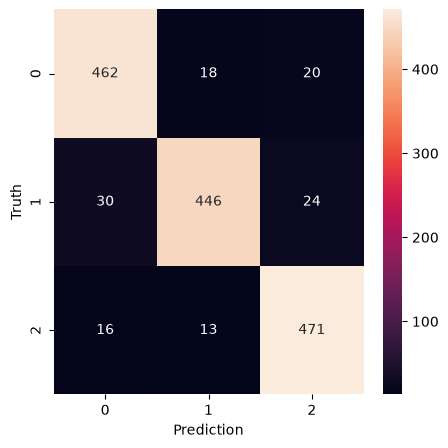

In [60]:
# Print the confusion Matrix with the best model got
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (5,5))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')